# Minimum Atomworks Output Analysis

This notebook reads `pdb.parquet` and `dataset.parquet` directly from a run output directory, summarizes the contents, and makes a few quick matplotlib plots for structure-, interface-, and dataset-level inspection.

Edit `OUT_DIR` in the next cell if you want to force a specific run directory.

In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)

out_dir = Path('/tmp/test_rosprep_no_rosetta')

pdb_path = out_dir / 'pdb.parquet'
dataset_path = out_dir / 'dataset.parquet'
run_metadata_path = out_dir / 'run_metadata.json'
dataset_metadata_path = out_dir / 'dataset_metadata.json'

print(f'Using out_dir: {out_dir}')
print(f'pdb.parquet exists: {pdb_path.exists()}')
print(f'dataset.parquet exists: {dataset_path.exists()}')
print(f'run_metadata.json exists: {run_metadata_path.exists()}')
print(f'dataset_metadata.json exists: {dataset_metadata_path.exists()}')

Using out_dir: /tmp/test_rosprep_no_rosetta
pdb.parquet exists: True
dataset.parquet exists: True
run_metadata.json exists: True
dataset_metadata.json exists: False


In [2]:
dataset_df = pd.read_parquet(dataset_path)
print(f'dataset_df shape: {dataset_df.shape}')
display(dataset_df.head(30))

dataset_df shape: (7, 10)


,analysis,key,value,source,pair,n_rows,n_unique_paths,mean_contact_atom_pairs,mean_left_interface_residues,mean_right_interface_residues
0,dataset_annotations,n_interface_rows,5,derived,None,NaN,NaN,NaN,NaN,NaN
1,dataset_annotations,n_unique_structures,5,derived,None,NaN,NaN,NaN,NaN,NaN
2,dataset_annotations,n_role_rows,20,derived,None,NaN,NaN,NaN,NaN,NaN
3,dataset_annotations,dataset_id,test_rosprep,config,None,NaN,NaN,NaN,NaN,NaN
4,dataset_annotations,dataset_name,test_rosprep,config,None,NaN,NaN,NaN,NaN,NaN
5,dataset_annotations,modality,antibody_antigen,config,None,NaN,NaN,NaN,NaN,NaN
6,interface_summary,None,None,None,antibody__antigen,5.0,5.0,686.8,32.0,31.2


In [3]:
# read pdb.parquet
pdb_df = pd.read_parquet(pdb_path)
print(f'pdb_df shape: {pdb_df.shape}')
display(pdb_df.head(20))

pdb_df shape: (45, 126)


,path,assembly_id,grain,chain_id,role,pair,role_left,role_right,sub_id,source__name,source__format,source__size_bytes,source__mtime_ns,source__n_atoms_loaded,source__n_chains_loaded,continuity__has_break,continuity__n_breaks,clash__has_clash,clash__n_clashing_atom_pairs,clash__n_clashing_atoms,center__centroid_x,center__centroid_y,center__centroid_z,rosprep__reference_path,rosprep__on_chains,rosprep__anchor_atoms,rosprep__alignment_method,rosprep__shared_atoms_rmsd,rosprep__shared_atoms_count,rosprep__rosetta_steps_applied,rosprep__rmsd,rosprep__matched_atoms,prepared__path,id__n_atoms_total,id__n_chains,id__has_nan_coord,id__n_atoms,chstat__n_residues,chstat__centroid_x,chstat__centroid_y,chstat__centroid_z,chstat__radius_of_gyration,rolseq__chain_ids,rolseq__n_chains,rolseq__sequence_length_total,rolseq__sequence,rolseq__sequence_by_chain,rolstat__n_residues,rolstat__centroid_x,rolstat__centroid_y,rolstat__centroid_z,rolstat__radius_of_gyration,abcdr__chain_ids,abcdr__numbering_scheme,abcdr__cdr_definition,abcdr__sequence_length,abcdr__cdr1_length,abcdr__cdr2_length,abcdr__cdr3_length,abseq__chain_ids,abseq__numbering_scheme,abseq__cdr_definition,abseq__sequence_length,abseq__cdr1_sequence,abseq__cdr2_sequence,abseq__cdr3_sequence,iface__contact_distance,iface__n_contact_atom_pairs,iface__n_left_contact_atoms,iface__n_right_contact_atoms,iface__n_left_interface_residues,iface__n_right_interface_residues,iface__left_interface_residues,iface__right_interface_residues,iface__n_left_vh_cdr1_interface_residues,iface__left_vh_cdr1_interface_residues,iface__n_left_vh_cdr2_interface_residues,iface__left_vh_cdr2_interface_residues,iface__n_left_vh_cdr3_interface_residues,iface__left_vh_cdr3_interface_residues,iface__n_left_vl_cdr1_interface_residues,iface__left_vl_cdr1_interface_residues,iface__n_left_vl_cdr2_interface_residues,iface__left_vl_cdr2_interface_residues,iface__n_left_vl_cdr3_interface_residues,iface__left_vl_cdr3_interface_residues,ifm__contact_distance,ifm__cell_size,ifm__n_residue_contact_pairs,ifm__residue_contact_pairs,ifm__left_interface_residue_labels,ifm__right_interface_residue_labels,ifm__left_n_interface_residues,ifm__left_interface_charge_sum,ifm__left_interface_hydrophobic_fraction,ifm__left_interface_polar_fraction,ifm__left_interface_aromatic_fraction,ifm__left_interface_glycine_fraction,ifm__left_interface_proline_fraction,ifm__right_n_interface_residues,ifm__right_interface_charge_sum,ifm__right_interface_hydrophobic_fraction,ifm__right_interface_polar_fraction,ifm__right_interface_aromatic_fraction,ifm__right_interface_glycine_fraction,ifm__right_interface_proline_fraction,pdockq__contact_distance,pdockq__n_contacts,pdockq__avg_interface_plddt,pdockq__pdockq,dataset__id,dataset__name,cluster__left_cluster_id,cluster__left_cluster_size,cluster__left_representative_path,cluster__left_distance_to_representative,cluster__left_n_points,cluster__left_interface_side,cluster__left_mode,cluster__right_cluster_id,cluster__right_cluster_size,cluster__right_representative_path,cluster__right_distance_to_representative,cluster__right_n_points,cluster__right_interface_side,cluster__right_mode
0,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,,,,,,None,None,NaN,NaN,NaN,NaN,True,1.0,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,NaN,NaN,None,0.000009,906.0,None,NaN,NaN,None,906.0,115.0,5.403358,-27.414461,-16.556015,13.989815,None,NaN,NaN,None,None,NaN,NaN,NaN,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,None,NaN,NaN,NaN,None,None,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,test_rosprep,test_rosprep,NaN,NaN,None,NaN,NaN,None,None,NaN,NaN,None,NaN,NaN,None,None
1,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,B,,,,,,None,None,NaN,NaN,NaN,NaN,False,0.0,None,NaN,NaN,NaN,NaN,NaN,None,None,NaN,None,NaN,NaN,None,0.000006,1634.0,None,NaN,NaN,None,1634.0,212.0,6.8162

In [4]:
# seperating this one dataset based on the grain column 
# only keep the column is they are not all Nan
grains = pdb_df['grain'].unique()
grain_dfs = {}
for grain in grains:
    grain_df = pdb_df[pdb_df['grain'] == grain]
    # drop columns that are all NaN
    grain_df = grain_df.dropna(axis=1, how='all')
    # drop columns that is empty string
    grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')
    grain_dfs[grain] = grain_df
    print(f'Grain: {grain}, shape: {grain_df.shape}')
    display(grain_df.head(20))
    
    

Grain: chain, shape: (15, 16)


/tmp/ipykernel_116013/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


,path,assembly_id,grain,chain_id,continuity__has_break,continuity__n_breaks,rosprep__rmsd,rosprep__matched_atoms,id__n_atoms,chstat__n_residues,chstat__centroid_x,chstat__centroid_y,chstat__centroid_z,chstat__radius_of_gyration,dataset__id,dataset__name
0,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,True,1.0,0.000009,906.0,906.0,115.0,5.403358,-27.414461,-16.556015,13.989815,test_rosprep,test_rosprep
1,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,B,False,0.0,0.000006,1634.0,1634.0,212.0,6.816290,6.250148,8.639813,22.622969,test_rosprep,test_rosprep
2,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,C,True,1.0,0.000006,1563.0,1563.0,209.0,-7.932692,8.481285,-1.935886,21.807119,test_rosprep,test_rosprep
9,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,True,1.0,0.368603,906.0,906.0,115.0,5.423154,-27.442211,-16.535191,14.001739,test_rosprep,test_rosprep
10,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,B,False,0.0,0.896319,1634.0,1634.0,212.0,7.016100,6.518949,8.178153,22.677553,test_rosprep,test_rosprep
11,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,C,True,1.0,0.833551,1563.0,1563.0,209.0,-7.942517,8.363685,-2.303626,21.629033,test_rosprep,test_rosprep
18,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,True,1.0,0.695185,906.0,906.0,115.0,5.334692,-27.626274,-16.715107,14.084042,test_rosprep,test_rosprep
19,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,B,False,0.0,0.383154,1634.0,1634.0,212.0,6.875018,6.376633,8.687148,22.695877,test_rosprep,test_rosprep
20,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,C,True,1.0,0.430126,1563.0,1563.0,209.0,-7.942098,8.456494,-1.939663,21.676346,test_rosprep,test_rosprep
27,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,chain,A,False,0.0,0.954549,906.0,906.0,115.0,5.315095,-27.558210,-16.525463,14.140637,test_rosprep,test_rosprep


Grain: interface, shape: (5, 64)


/tmp/ipykernel_116013/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


...

/tmp/ipykernel_116013/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


,path,assembly_id,grain,role,id__n_atoms,rolseq__chain_ids,rolseq__n_chains,rolseq__sequence_length_total,rolseq__sequence,rolseq__sequence_by_chain,rolstat__n_residues,rolstat__centroid_x,rolstat__centroid_y,rolstat__centroid_z,rolstat__radius_of_gyration,abcdr__chain_ids,abcdr__numbering_scheme,abcdr__cdr_definition,abcdr__sequence_length,abcdr__cdr1_length,abcdr__cdr2_length,abcdr__cdr3_length,abseq__chain_ids,abseq__numbering_scheme,abseq__cdr_definition,abseq__sequence_length,abseq__cdr1_sequence,abseq__cdr2_sequence,abseq__cdr3_sequence,dataset__id,dataset__name
4,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antibody,3197.0,B;C,2.0,421.0,NaN,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",421.0,-0.394426,7.340942,3.469394,24.043191,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None,test_rosprep,test_rosprep
5,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antigen,906.0,A,1.0,115.0,WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMSPSNQTD...,"{""A"":""WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMS...",115.0,5.403358,-27.414461,-16.556015,13.989815,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None,test_rosprep,test_rosprep
6,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,vh,1563.0,C,1.0,209.0,QVQLVESGGGLVKPGGSLRLSCAASGFTFSNYGMSWIRQAPGKGLE...,"{""C"":""QVQLVESGGGLVKPGGSLRLSCAASGFTFSNYGMSWIRQA...",209.0,-7.932692,8.481285,-1.935886,21.807119,C,imgt,imgt,209.0,8.0,8.0,9.0,C,imgt,imgt,209.0,GFTFSNYG,ISGGGSNI,VSYYYGIDF,test_rosprep,test_rosprep
7,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,vl,1634.0,B,1.0,212.0,DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKPGKAPKL...,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",212.0,6.816290,6.250148,8.639813,22.622969,B,imgt,imgt,212.0,6.0,3.0,9.0,B,imgt,imgt,212.0,QDVTTA,WAS,QQHYTIPWT,test_rosprep,test_rosprep
13,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antibody,3197.0,B;C,2.0,421.0,NaN,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",421.0,-0.297111,7.420831,3.053656,24.004786,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None,test_rosprep,test_rosprep
14,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antigen,906.0,A,1.0,115.0,WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMSPSNQTD...,"{""A"":""WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMS...",115.0,5.423154,-27.442211,-16.535191,14.001739,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None,test_rosprep,test_rosprep
15,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,vh,1563.0,C,1.0,209.0,QVQLVESGGGLVKPGGSLRLSCAASGFTFSNYGMSWIRQAPGKGLE...,"{""C"":""QVQLVESGGGLVKPGGSLRLSCAASGFTFSNYGMSWIRQA...",209.0,-7.942517,8.363685,-2.303626,21.629033,C,imgt,imgt,209.0,8.0,8.0,9.0,C,imgt,imgt,209.0,GFTFSNYG,ISGGGSNI,VSYYYGIDF,test_rosprep,test_rosprep
16,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,vl,1634.0,B,1.0,212.0,DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKPGKAPKL...,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",212.0,7.016100,6.518949,8.178153,22.677553,B,imgt,imgt,212.0,6.0,3.0,9.0,B,imgt,imgt,212.0,QDVTTA,WAS,QQHYTIPWT,test_rosprep,test_rosprep
22,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antibody,3197.0,B;C,2.0,421.0,NaN,"{""B"":""DIQMTQSPSSLSASVGDRVTITCKASQDVTTAVAWYQQKP...",421.0,-0.369004,7.393465,3.491744,24.033189,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None,test_rosprep,test_rosprep
23,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,role,antigen,906.0,A,1.0,115.0,WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMSPSNQTD...,"{""A"":""WNPPTFSPALLVVTEGDNATFTCSFSNTSESFVLNWYRMS...",115.0,5.334692,-27.626274,-16.715107,14.084042,None,None,None,NaN,NaN,NaN,NaN,None,None,None,NaN,None,None,None,test_rosprep,test_rosprep


Grain: structure, shape: (5, 28)


/tmp/ipykernel_116013/3720883804.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  grain_df = grain_df.replace('', np.nan).dropna(axis=1, how='all')


,path,assembly_id,grain,source__name,source__format,source__size_bytes,source__mtime_ns,source__n_atoms_loaded,source__n_chains_loaded,clash__has_clash,clash__n_clashing_atom_pairs,clash__n_clashing_atoms,center__centroid_x,center__centroid_y,center__centroid_z,rosprep__reference_path,rosprep__on_chains,rosprep__anchor_atoms,rosprep__alignment_method,rosprep__shared_atoms_rmsd,rosprep__shared_atoms_count,rosprep__rosetta_steps_applied,prepared__path,id__n_atoms_total,id__n_chains,id__has_nan_coord,dataset__id,dataset__name
8,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,7e9b_ag_C_ab_L_H_unrelaxed_rank_001_alphafold2...,pdb,332829.0,1.770066e+18,4103.0,3.0,True,12.0,18.0,0.885804,-0.333535,-0.952488,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,443.0,homologs,0.000007,4103.0,False,/tmp/test_rosprep_no_rosetta/_prepared/structu...,4103.0,3.0,False,test_rosprep,test_rosprep
17,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,7e9b_ag_C_ab_L_H_unrelaxed_rank_002_alphafold2...,pdb,332829.0,1.770066e+18,4103.0,3.0,True,11.0,19.0,0.838313,-0.438043,-0.998483,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,268.0,homologs,0.783982,4103.0,False,/tmp/test_rosprep_no_rosetta/_prepared/structu...,4103.0,3.0,False,test_rosprep,test_rosprep
26,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,7e9b_ag_C_ab_L_H_unrelaxed_rank_003_alphafold2...,pdb,332829.0,1.770066e+18,4103.0,3.0,True,12.0,19.0,0.784270,-0.330999,-1.042894,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,498.0,homologs,0.485446,4103.0,False,/tmp/test_rosprep_no_rosetta/_prepared/structu...,4103.0,3.0,False,test_rosprep,test_rosprep
35,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,7e9b_ag_C_ab_L_H_unrelaxed_rank_004_alphafold2...,pdb,332829.0,1.770066e+18,4103.0,3.0,True,15.0,24.0,0.786609,0.592466,-1.633959,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,306.0,homologs,5.221178,4103.0,False,/tmp/test_rosprep_no_rosetta/_prepared/structu...,4103.0,3.0,False,test_rosprep,test_rosprep
44,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,structure,7e9b_ag_C_ab_L_H_unrelaxed_rank_005_alphafold2...,pdb,332829.0,1.770066e+18,4103.0,3.0,True,22.0,32.0,-1.155203,0.629957,-1.042058,/home/eva/20260202_atomworks_plug_play/atw_pp/...,A;B;C,290.0,homologs,5.759705,4103.0,False,/tmp/test_rosprep_no_rosetta/_prepared/structu...,4103.0,3.0,False,test_rosprep,test_rosprep


interface_df shape: (5, 64)


,path,assembly_id,grain,pair,role_left,role_right,iface__contact_distance,iface__n_contact_atom_pairs,iface__n_left_contact_atoms,iface__n_right_contact_atoms,iface__n_left_interface_residues,iface__n_right_interface_residues,iface__left_interface_residues,iface__right_interface_residues,iface__n_left_vh_cdr1_interface_residues,iface__left_vh_cdr1_interface_residues,iface__n_left_vh_cdr2_interface_residues,iface__left_vh_cdr2_interface_residues,iface__n_left_vh_cdr3_interface_residues,iface__left_vh_cdr3_interface_residues,iface__n_left_vl_cdr1_interface_residues,iface__left_vl_cdr1_interface_residues,iface__n_left_vl_cdr2_interface_residues,iface__left_vl_cdr2_interface_residues,iface__n_left_vl_cdr3_interface_residues,iface__left_vl_cdr3_interface_residues,ifm__contact_distance,ifm__cell_size,ifm__n_residue_contact_pairs,ifm__residue_contact_pairs,ifm__left_interface_residue_labels,ifm__right_interface_residue_labels,ifm__left_n_interface_residues,ifm__left_interface_charge_sum,ifm__left_interface_hydrophobic_fraction,ifm__left_interface_polar_fraction,ifm__left_interface_aromatic_fraction,ifm__left_interface_glycine_fraction,ifm__left_interface_proline_fraction,ifm__right_n_interface_residues,ifm__right_interface_charge_sum,ifm__right_interface_hydrophobic_fraction,ifm__right_interface_polar_fraction,ifm__right_interface_aromatic_fraction,ifm__right_interface_glycine_fraction,ifm__right_interface_proline_fraction,pdockq__contact_distance,pdockq__n_contacts,dataset__id,dataset__name,cluster__left_cluster_id,cluster__left_cluster_size,cluster__left_representative_path,cluster__left_distance_to_representative,cluster__left_n_points,cluster__left_interface_side,cluster__left_mode,cluster__right_cluster_id,cluster__right_cluster_size,cluster__right_representative_path,cluster__right_distance_to_representative,cluster__right_n_points,cluster__right_interface_side,cluster__right_mode
3,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,interface,antibody__antigen,antibody,antigen,5.0,743.0,162.0,146.0,32.0,31.0,B:31:T;B:32:A;B:48:I;B:49:Y;B:50:W;B:52:S;B:53...,A:32:F;A:33:V;A:34:L;A:35:N;A:37:Y;A:40:S;A:42...,4.0,C:26:G;C:27:F;C:31:N;C:32:Y,0.0,NaN,6.0,C:99:Y;C:100:Y;C:101:Y;C:102:G;C:104:D;C:105:F,2.0,B:31:T;B:32:A,2.0,B:50:W;B:52:S,5.0,B:91:H;B:92:Y;B:93:T;B:94:I;B:96:W,5.0,5.0,88.0,B:31:T|A:103:I;B:32:A|A:101:A;B:48:I|A:44:Q;B:...,B:31;B:32;B:48;B:49;B:50;B:52;B:53;B:54;B:55;B...,A:32;A:33;A:34;A:35;A:37;A:40;A:42;A:43;A:44;A...,32.0,0.0,0.500000,0.343750,0.437500,0.093750,0.0,31.0,-1.0,0.451613,0.354839,0.096774,0.032258,0.096774,8.0,61.0,test_rosprep,test_rosprep,1.0,5.0,/home/eva/20260202_atomworks_plug_play/atw_pp/...,0.091590,32.0,left,interface_ca,1.0,5.0,/home/eva/20260202_atomworks_plug_play/atw_pp/...,0.350771,31.0,right,interface_ca
12,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,interface,antibody__antigen,antibody,antigen,5.0,722.0,162.0,147.0,32.0,32.0,B:31:T;B:32:A;B:48:I;B:49:Y;B:50:W;B:52:S;B:53...,A:32:F;A:33:V;A:34:L;A:35:N;A:37:Y;A:40:S;A:42...,4.0,C:26:G;C:27:F;C:31:N;C:32:Y,0.0,NaN,6.0,C:99:Y;C:100:Y;C:101:Y;C:102:G;C:104:D;C:105:F,2.0,B:31:T;B:32:A,2.0,B:50:W;B:52:S,5.0,B:91:H;B:92:Y;B:93:T;B:94:I;B:96:W,5.0,5.0,90.0,B:31:T|A:103:I;B:32:A|A:101:A;B:48:I|A:44:Q;B:...,B:31;B:32;B:48;B:49;B:50;B:52;B:53;B:54;B:55;B...,A:32;A:33;A:34;A:35;A:37;A:40;A:42;A:43;A:44;A...,32.0,0.0,0.500000,0.343750,0.437500,0.093750,0.0,32.0,-1.0,0.468750,0.343750,0.093750,0.031250,0.093750,8.0,61.0,test_rosprep,test_rosprep,1.0,5.0,/home/eva/20260202_atomworks_plug_play/atw_pp/...,0.000000,32.0,left,interface_ca,1.0,5.0,/home/eva/20260202_atomworks_plug_play/atw_pp/...,0.000000,32.0,right,interface_ca
21,/home/eva/20260202_atomworks_plug_play/atw_pp/...,1,interface,antibody__antigen,antibody,antigen,5.0,678.0,152.0,144.0,31.0,31.0,B:31:T;B:32:A;B:49:Y;B:50:W;B:52:S;B:53:T;B:54...,A:32:F;A:33:V;A:34:L;A:35:N;A:37:Y;A:40:S;A:43...,4.0,C:26:G;C:27:F;C:31:N;C:32:Y,0.0,NaN,6.0,C:99:Y;C:100:Y;C:101:Y;C:102:G;C:104:D;C:105:F,2.0

Correlation matrix for numeric columns in interface_df:


,iface__contact_distance,iface__n_contact_atom_pairs,iface__n_left_contact_atoms,iface__n_right_contact_atoms,iface__n_left_interface_residues,iface__n_right_interface_residues,iface__n_left_vh_cdr1_interface_residues,iface__n_left_vh_cdr2_interface_residues,iface__n_left_vh_cdr3_interface_residues,iface__n_left_vl_cdr1_interface_residues,iface__n_left_vl_cdr2_interface_residues,iface__n_left_vl_cdr3_interface_residues,ifm__contact_distance,ifm__cell_size,ifm__n_residue_contact_pairs,ifm__left_n_interface_residues,ifm__left_interface_charge_sum,ifm__left_interface_hydrophobic_fraction,ifm__left_interface_polar_fraction,ifm__left_interface_aromatic_fraction,ifm__left_interface_glycine_fraction,ifm__left_interface_proline_fraction,ifm__right_n_interface_residues,ifm__right_interface_charge_sum,ifm__right_interface_hydrophobic_fraction,ifm__right_interface_polar_fraction,ifm__right_interface_aromatic_fraction,ifm__right_interface_glycine_fraction,ifm__right_interface_proline_fraction,pdockq__contact_distance,pdockq__n_contacts,cluster__left_cluster_id,cluster__left_cluster_size,cluster__left_distance_to_representative,cluster__left_n_points,cluster__right_cluster_id,cluster__right_cluster_size,cluster__right_distance_to_representative,cluster__right_n_points
iface__contact_distance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iface__n_contact_atom_pairs,NaN,1.000000,0.932038,0.864304,0.071999,0.652785,0.022768,-0.697974,0.697974,NaN,NaN,NaN,NaN,NaN,0.606305,0.071999,NaN,0.058627,0.002732,-0.073328,-0.030272,NaN,0.652785,NaN,-0.987783,0.795962,-0.679695,-0.162497,-0.679695,NaN,-0.022768,NaN,NaN,-0.581911,0.071999,NaN,NaN,-0.619404,0.652785
iface__n_left_contact_atoms,NaN,0.932038,1.000000,0.798704,0.301841,0.621635,0.057270,-0.529958,0.529958,NaN,NaN,NaN,NaN,NaN,0.768361,0.301841,NaN,0.308080,-0.036668,-0.308919,-0.093113,NaN,0.621635,NaN,-0.901162,0.830115,-0.638877,-0.483326,-0.638877,NaN,-0.057270,NaN,NaN,-0.547150,0.301841,NaN,NaN,-0.600580,0.621635
iface__n_right_contact_atoms,NaN,0.864304,0.798704,1.000000,0.321911,0.943811,0.458088,-0.394807,0.394807,NaN,NaN,NaN,NaN,NaN,0.796690,0.321911,NaN,-0.319222,0.461289,-0.313772,-0.450734,NaN,0.943811,NaN,-0.785012,0.417843,-0.955629,-0.152194,-0.955629,NaN,-0.458088,NaN,NaN,-0.179372,0.321911,NaN,NaN,-0.265833,0.943811
iface__n_left_interface_residues,NaN,0.071999,0.301841,0.321911,1.000000,0.476731,0.790569,0.645497,-0.645497,NaN,NaN,NaN,NaN,NaN,0.707107,1.000000,NaN,0.040311,0.635816,-0.999707,-0.840335,NaN,0.476731,NaN,0.014259,-0.159823,-0.444359,-0.828974,-0.444359,NaN,-0.790569,NaN,NaN,0.561933,1.000000,NaN,NaN,0.506645,0.476731
iface__n_right_interface_residues,NaN,0.652785,0.621635,0.943811,0.476731,1.000000,0.678401,-0.123091,0.123091,NaN,NaN,NaN,NaN,NaN,0.842750,0.476731,NaN,-0.472748,0.683141,-0.464677,-0.667510,NaN,1.000000,NaN,-0.537558,0.129823,-0.999025,-0.181022,-0.999025,NaN,-0.678401,NaN,NaN,0.103322,0.476731,NaN,NaN,-0.006304,1.000000
iface__n_left_vh_cdr1_interface_residues,NaN,0.022768,0.057270,0.458088,0.790569,0.678401,1.000000,0.612372,-0.612372,NaN,NaN,NaN,NaN,NaN,0.559017,0.790569,NaN,-0.580006,0.975311,-0.775519,-0.996290,NaN,0.678401,NaN,0.082656,-0.499405,-0.649520,-0.316406,-0.649520,NaN,-1.000000,NaN,NaN,0.783415,0.790569,NaN,NaN,0.716793,0.678401
iface__n_left_vh_cdr2_interface_residues,NaN,-0.697974,-0.529958,-0.394807,0.645497,-0.123091,0.612372,1.000000,-1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.645497,NaN,-0.140511,0.539057,-0.641275,-0.632778,NaN,-0.123091,NaN,0.744996,-0.778764,0.165794,-0.385945,0.165794,NaN,-0.612372,NaN,NaN,0.909669,0.645497,NaN,NaN,0.907081,-0.123091
iface__n_left_vh_cdr3_interface_residues,NaN,0.697974,0.529958,0.394807,-0.645497,0.123091,-0.612372,-1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,-0.645497,NaN,0.140511,-0.539057,0.641275,0.632778,NaN,0.123091,NaN,-0.744996,0.778764,-0.165794,0.385945,-0.165794,NaN,0.

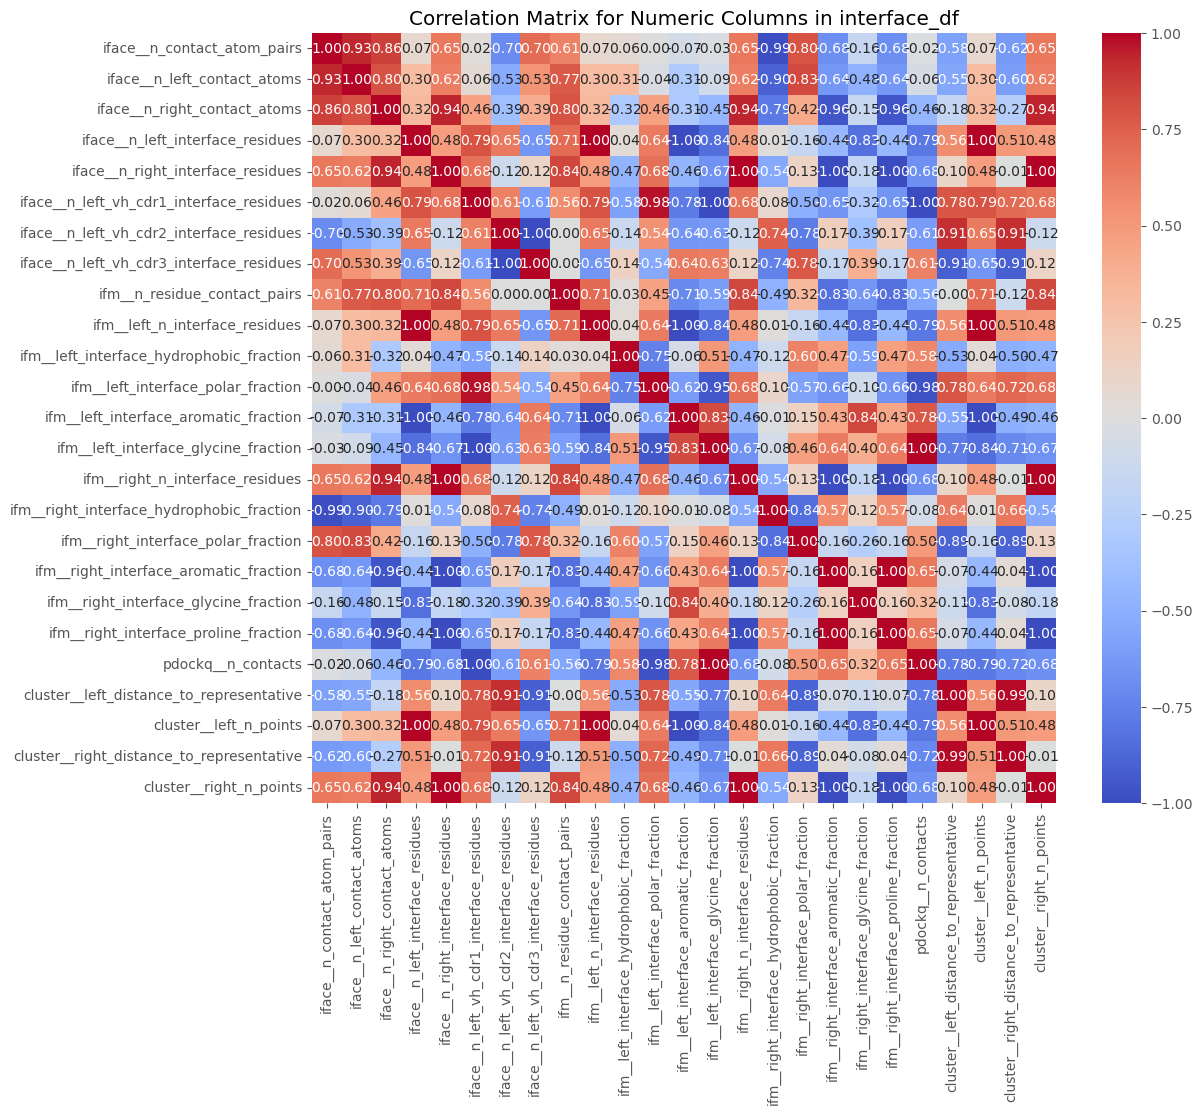

In [5]:
# data analysis for grain == interface
interface_df = grain_dfs['interface']
print(f'interface_df shape: {interface_df.shape}')
display(interface_df.head(20))

# check correlation between columns in interface_df for numeric columns
numeric_cols = interface_df.select_dtypes(include=[np.number]).columns
correlation_matrix = interface_df[numeric_cols].corr()
print('Correlation matrix for numeric columns in interface_df:')
display(correlation_matrix)

# plot correlation matrix as heatmap for column that is not all NaN
import seaborn as sns
correlation_matrix = correlation_matrix.dropna(axis=0, how='all').dropna(axis=1, how='all')
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix for Numeric Columns in interface_df')
plt.show()

